In [1]:
import cv2
from helper import*
import matplotlib.pyplot as plt
import math
import numpy as np 
import os
from dotenv import load_dotenv


In [2]:
load_dotenv() 
video_2_frame_path = os.getenv("video_2_frame_path")
video_4_frame_path = os.getenv("output_path")
output_path = os.getenv("my_results")
video_path = os.getenv("video_path")
my_results = os.getenv("my_results")

In [3]:
# extract_frames(video_path , output_path)

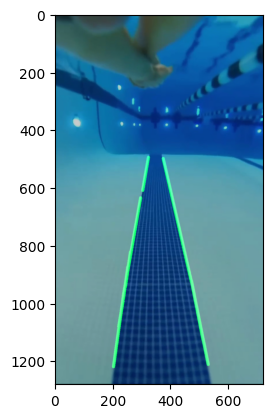

In [4]:
image = cv2.imread(video_2_frame_path)
hsv_image = hsv_mask(image)
canny_image = canny(hsv_image)
cropped_image = roi(canny_image)
lines_to_draw = []
w = image.shape[1]
lines = cv2.HoughLinesP(cropped_image, 2, np.pi/180, 100, np.array([]),
                        minLineLength=20, maxLineGap=35)



# ── Vertical filter ──────────────────────────────────────────────────────
vertical_lines = []
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        degrees = math.degrees(math.atan2(y2 - y1, x2 - x1)) % 360
        if (70 <= degrees <= 110) or (250 <= degrees <= 290):
            vertical_lines.append(line)

vertical_lines = np.array(vertical_lines) if vertical_lines else None
# ──────────────────────────────────────────────────────────────────────────

line_image = display_lines(image, vertical_lines)
result = draw_lanes_on_image(image, vertical_lines)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
